# Layer Average Temperature Analysis

This notebook analyzes the average temperature of specific layers according to their Z coordinates over the entire timeframe of the dataset.
It uses chunked processing to prevent memory errors when dealing with large datasets.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import warnings
import datetime
import os
warnings.filterwarnings('ignore')
# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# =============================================================================
# CONFIGURATION: Target Layers
# =============================================================================
# Define the Z-coordinate layers you want to analyze.
target_layers = [4727, 5177, 6177]

# =============================================================================
# 1. Load thermocouple metadata
tc_meta = pd.read_csv('thermocouples.csv')
tc_meta.columns = tc_meta.columns.str.strip()  # Clean col names

# Standardize ID column
id_col_meta = next((c for c in ['Sl. No.', 'Sl No.', 'no.'] if c in tc_meta.columns), None)
if id_col_meta:
    tc_meta = tc_meta.rename(columns={id_col_meta: 'TC_ID'})

# Map TC_ID -> Z
tc_z_map = tc_meta.set_index('TC_ID')['Z'].to_dict()

print(f"Thermocouple metadata loaded: {len(tc_meta)} records.")

# 2. Identify the dataset to use
data_file = 'value_rf_imputed.csv' if os.path.exists('value_rf_imputed.csv') else 'thermocouple_data_final.csv'
print(f"Processing data from {data_file} in chunks...")

# Fast check headers to config chunk reader
sample_df = pd.read_csv(data_file, nrows=2)

id_col_data = next((c for c in ['Sl. No.', 'Sl No.', 'no.'] if c in sample_df.columns), None)
value_col = 'VALUE_rf_imputed' if 'VALUE_rf_imputed' in sample_df.columns else 'VALUE'

usecols = ['MEASUREDATE', id_col_data, value_col]
dtypes = {id_col_data: 'int32', value_col: 'float32'}

# 3. Stream data using chunking
chunk_size = 500000
agg_chunks = []

reader = pd.read_csv(
    data_file,
    usecols=usecols,
    dtype=dtypes,
    chunksize=chunk_size
)

for i, chunk in enumerate(reader):
    # Standardize ID
    chunk = chunk.rename(columns={id_col_data: 'TC_ID'})
    
    # Map ID to Z score
    chunk['Z'] = chunk['TC_ID'].map(tc_z_map)
    
    # Filter exactly for target_layers
    if target_layers:
        chunk = chunk[chunk['Z'].isin(target_layers)]
        
    if chunk.empty:
        continue
        
    # Parse dates efficiently
    try:
         chunk['MEASUREDATE'] = pd.to_datetime(chunk['MEASUREDATE'], format='%d-%m-%Y', errors='coerce')
    except:
         chunk['MEASUREDATE'] = pd.to_datetime(chunk['MEASUREDATE'], errors='coerce')
         
    chunk = chunk.dropna(subset=['MEASUREDATE', 'Z', value_col])
    
    # Calculate partial aggregate (sum & count to accurately mean later)
    chunk_agg = chunk.groupby(['MEASUREDATE', 'Z'])[value_col].agg(['sum', 'count']).reset_index()
    agg_chunks.append(chunk_agg)

# 4. Combine partial aggregates to calculate actual final mean per layer/date
if agg_chunks:
    full_agg = pd.concat(agg_chunks, ignore_index=True)
    final_daily = full_agg.groupby(['MEASUREDATE', 'Z']).agg({'sum': 'sum', 'count': 'sum'}).reset_index()
    final_daily[value_col] = final_daily['sum'] / final_daily['count']
    
    # Pivot
    layer_avg_pivot = final_daily.pivot(index='MEASUREDATE', columns='Z', values=value_col)
    layer_avg_pivot = layer_avg_pivot.sort_index()
    print("Data processing successfully completed.")
else:
    layer_avg_pivot = pd.DataFrame()
    print("No data found matching the target layers.")

layer_avg_pivot.head()

Thermocouple metadata loaded: 506 records.
Processing data from value_rf_imputed.csv in chunks...
Data processing successfully completed.


Z,4727,5177,6177
MEASUREDATE,,,
2016-03-29,62.979592,NaN,320.993802
2019-10-09,97.264600,142.269870,243.993403
2019-10-10,95.304600,142.093471,238.940808
2019-10-11,78.961733,141.901088,242.897481
2019-10-12,85.728135,152.609455,263.394691


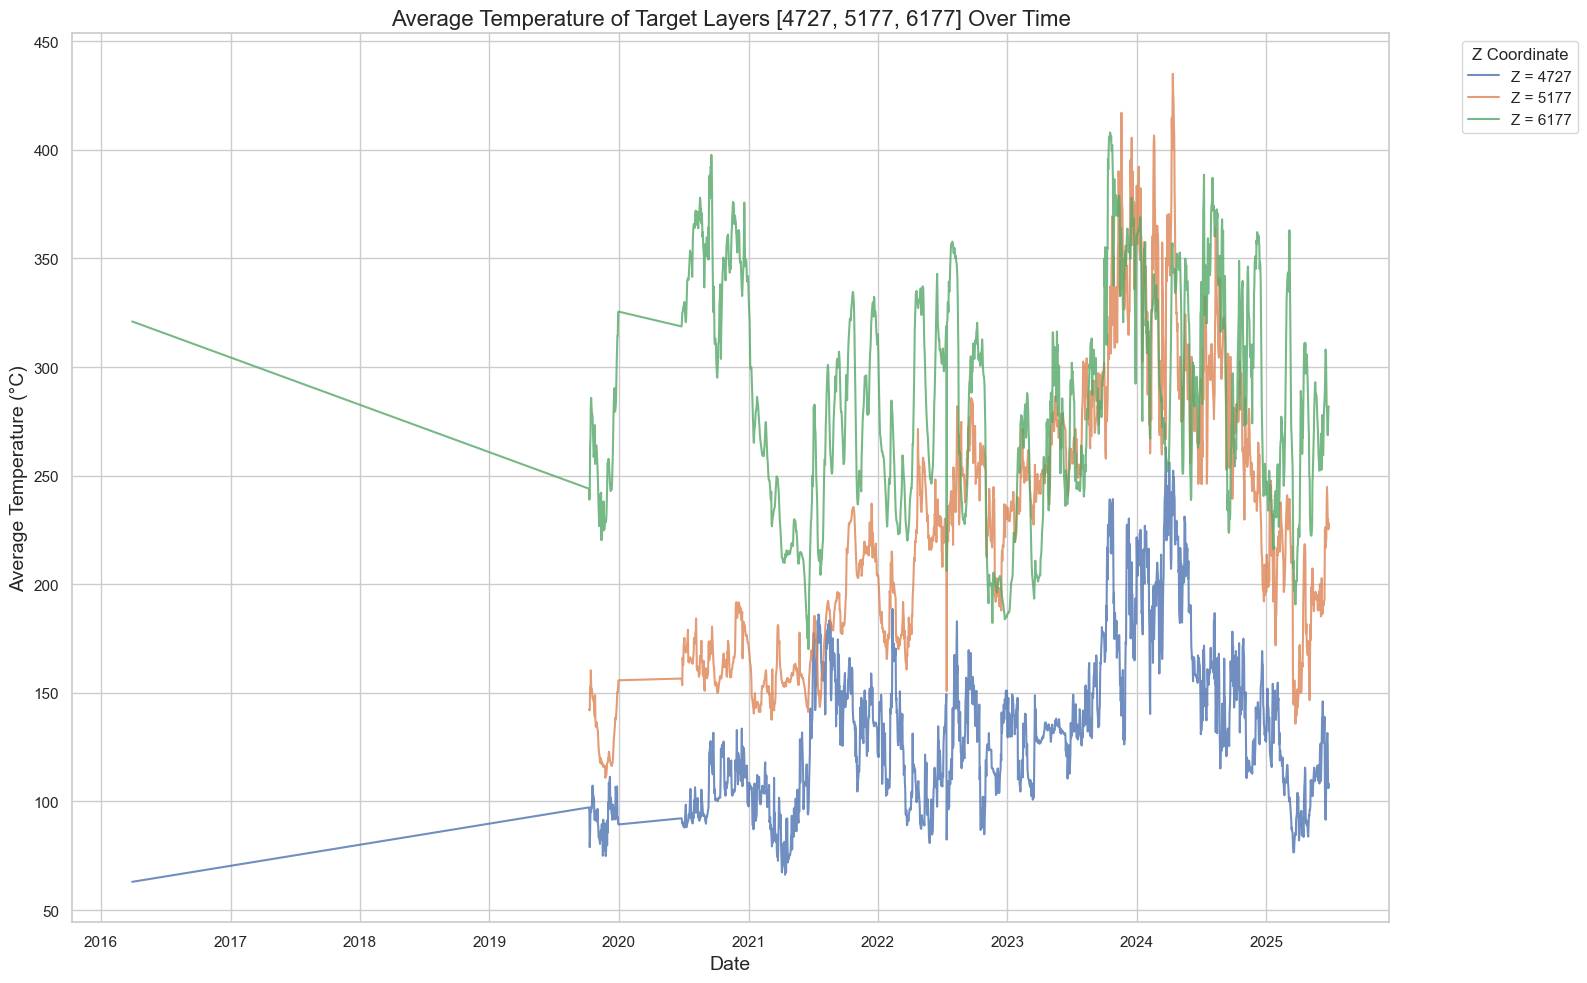

In [77]:
if not layer_avg_pivot.empty:
    # Plot the time series of average temperature for each Z layer
    plt.figure(figsize=(16, 10))

    for z_coord in sorted(layer_avg_pivot.columns):
        plt.plot(layer_avg_pivot.index, layer_avg_pivot[z_coord], label=f'Z = {z_coord}', alpha=0.8, linewidth=1.5)

    if target_layers:
        plt.title(f'Average Temperature of Target Layers {target_layers} Over Time', fontsize=16)
    else:
        plt.title('Average Temperature of Layers by Z Coordinate Over Time', fontsize=16)

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Average Temperature (\u00b0C)', fontsize=14)
    plt.legend(title='Z Coordinate', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### Smooth Data Visualization
Applying a rolling average helps visualize the long-term trends.

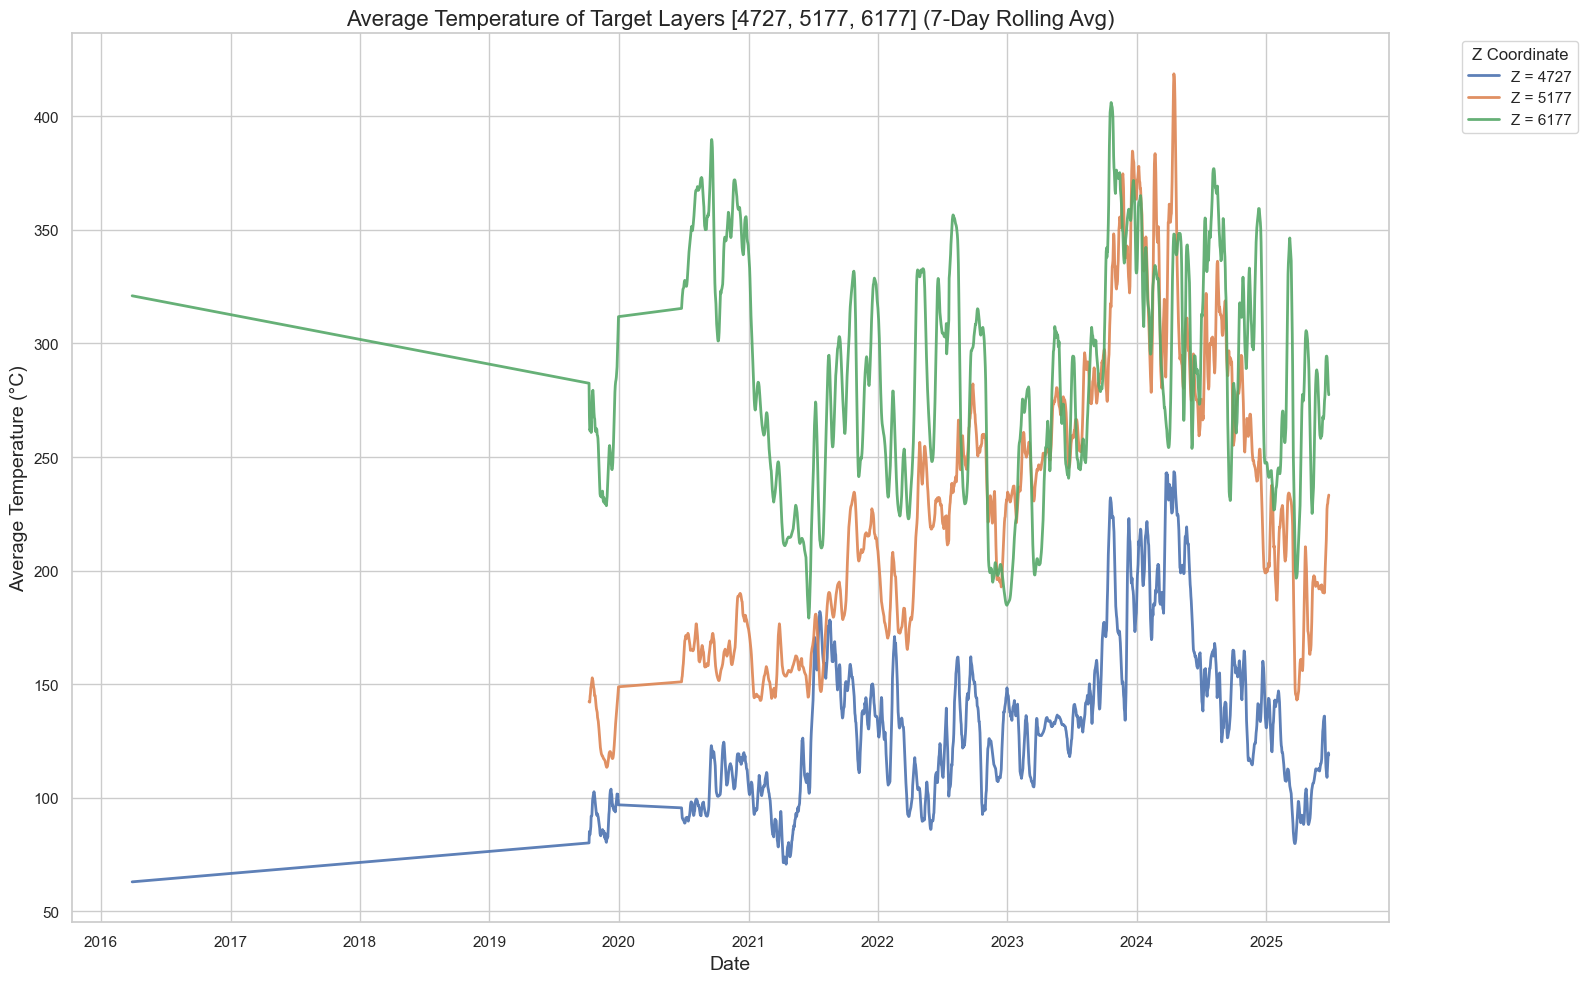

In [78]:
if not layer_avg_pivot.empty:
    # Plotting with a 7-day rolling average to smooth out noise
    plt.figure(figsize=(16, 10))

    rolling_window = 7 # Adjust this value if needed
    layer_avg_smooth = layer_avg_pivot.rolling(window=rolling_window, min_periods=1).mean()

    for z_coord in sorted(layer_avg_smooth.columns):
        plt.plot(layer_avg_smooth.index, layer_avg_smooth[z_coord], label=f'Z = {z_coord}', alpha=0.9, linewidth=2)

    if target_layers:
        plt.title(f'Average Temperature of Target Layers {target_layers} ({rolling_window}-Day Rolling Avg)', fontsize=16)
    else:
        plt.title(f'Average Temperature of Layers by Z Coordinate ({rolling_window}-Day Rolling Avg)', fontsize=16)

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Average Temperature (\u00b0C)', fontsize=14)
    plt.legend(title='Z Coordinate', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

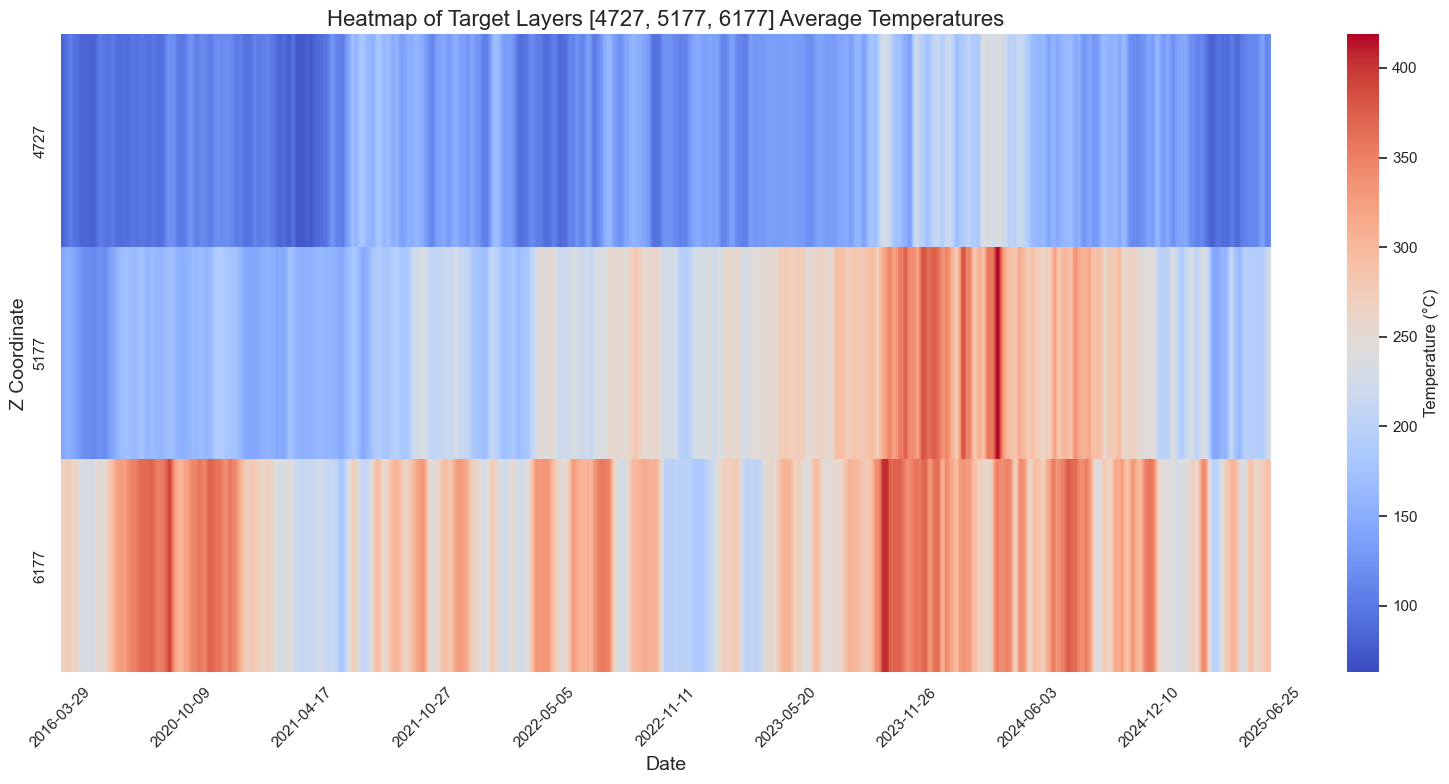

In [79]:
if not layer_avg_pivot.empty:
    # Heatmap visualization across Z coordinates over time
    plt.figure(figsize=(16, 8))
    # Transpose so Z coordinates are the Y-axis, Dates are X-axis
    sns.heatmap(layer_avg_smooth.T, cmap='coolwarm', cbar_kws={'label': 'Temperature (\u00b0C)'})

    # Format x-axis dates so they aren't crowded
    num_ticks = 10
    ticks = range(0, len(layer_avg_smooth.index), max(1, len(layer_avg_smooth.index)//num_ticks))
    plt.xticks(ticks, [layer_avg_smooth.index[i].strftime('%Y-%m-%d') for i in ticks], rotation=45)
    if target_layers:
        plt.title(f'Heatmap of Target Layers {target_layers} Average Temperatures', fontsize=16)
    else:
        plt.title('Heatmap of Layer Average Temperatures', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Z Coordinate', fontsize=14)
    plt.tight_layout()
    plt.show()

## 2D Top-Down Spatial Heatmaps for Specific Layers
To better analyze asymmetrical heating (e.g., hotspots on a specific wall), we can generate high-resolution 2D circular contour maps for specific Z-layers on a specific day using `scipy.interpolate`.

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_spatial_layer(date_pd, target_z):
    print(f"Processing spatial map for Z={target_z} on {date_pd.strftime('%Y-%m-%d')}...")
    # 1. Map TC_ID to X and Y arrays
    tc_x_map = tc_meta.set_index('TC_ID')['X'].to_dict()
    tc_y_map = tc_meta.set_index('TC_ID')['Y'].to_dict()
    
    # 2. Iterate through chunks again just for this specific date and layer
    layer_records = []
    reader = pd.read_csv(data_file, usecols=usecols, dtype=dtypes, chunksize=chunk_size)
    for chunk in reader:
        chunk = chunk.rename(columns={id_col_data: 'TC_ID'})
        chunk['Z'] = chunk['TC_ID'].map(tc_z_map)
        
        # Filter by Z-layer first
        chunk = chunk[chunk['Z'] == target_z]
        if chunk.empty: continue
        
        # Parse dates and filter to our target date
        try:
            chunk['MEASUREDATE'] = pd.to_datetime(chunk['MEASUREDATE'], format='%d-%m-%Y', errors='coerce')
        except:
            chunk['MEASUREDATE'] = pd.to_datetime(chunk['MEASUREDATE'], errors='coerce')
            
        chunk = chunk[chunk['MEASUREDATE'] == date_pd]
        if chunk.empty: continue
        
        layer_records.append(chunk)
        
    if not layer_records:
        print(f"No data found for Z={target_z} on {date_pd.strftime('%Y-%m-%d')}")
        return
        
    layer_data = pd.concat(layer_records, ignore_index=True)
    
    # Reconstruct X and Y
    layer_data['X'] = layer_data['TC_ID'].map(tc_x_map)
    layer_data['Y'] = layer_data['TC_ID'].map(tc_y_map)
    layer_data = layer_data.dropna(subset=['X', 'Y', value_col])
    
    # Group by TC to get the average reading for that specific date (in case of multiple entries)
    layer_grouped = layer_data.groupby(['TC_ID', 'X', 'Y'])[value_col].mean().reset_index()
    
    # Prepare coordinate geometries
    x_vals = layer_grouped['X'].values
    y_vals = layer_grouped['Y'].values
    temps = layer_grouped[value_col].values
    
    # Ensure we actually have variation/valid data
    if len(x_vals) < 4:
        print(f"Not enough thermocouples ({len(x_vals)}) to interpolate a 2D surface for Z={target_z}.")
        return
        
    # Create a mesh grid spanning the radius of the furnace layer
    radius = np.max(np.sqrt(x_vals**2 + y_vals**2)) * 1.1 # Add 10% padding boundary
    grid_res = 200
    grid_x, grid_y = np.mgrid[-radius:radius:complex(grid_res), -radius:radius:complex(grid_res)]
    
    # Interpolate using natural neighbor (cubic) or inverse distance (linear if cubic fails)
    try:
        grid_z = griddata((x_vals, y_vals), temps, (grid_x, grid_y), method='cubic')
    except:
        grid_z = griddata((x_vals, y_vals), temps, (grid_x, grid_y), method='linear')
        
    # Mask out values outside the actual furnace circular boundary
    dist_from_center = np.sqrt(grid_x**2 + grid_y**2)
    grid_z[dist_from_center > radius*0.95] = np.nan
    
    # Plotting
    plt.figure(figsize=(10, 8))
    # Contour map
    contour = plt.contourf(grid_x, grid_y, grid_z, levels=50, cmap='RdYlBu_r', alpha=0.8, vmin=np.nanmin(temps), vmax=np.nanmax(temps))
    plt.colorbar(contour, label='Temperature (°C)')
    
    # Scatter actual TC locations
    scatter = plt.scatter(x_vals, y_vals, c=temps, cmap='RdYlBu_r', edgecolors='black', s=100, linewidth=1, vmin=np.nanmin(temps), vmax=np.nanmax(temps))
    
    # Label TCs
    for i, txt in enumerate(layer_grouped['TC_ID']):
        plt.annotate(txt, (x_vals[i]+100, y_vals[i]+100), fontsize=8, alpha=0.7)
        
    # Draw Furnace Boundary
    circle = plt.Circle((0, 0), radius*0.95, color='black', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)

    # Add Sector Divisions (every 60 degrees)
    for angle in range(0, 360, 60):
        theta_rad = np.deg2rad(angle)
        x_end = radius * 0.95 * np.cos(theta_rad)
        y_end = radius * 0.95 * np.sin(theta_rad)
        plt.plot([0, x_end], [0, y_end], color='black', linestyle='--', alpha=0.3, linewidth=1)
        
        # Add degree labels
        label_r = radius * 1.03
        lx = label_r * np.cos(theta_rad)
        ly = label_r * np.sin(theta_rad)
        plt.text(lx, ly, f"{angle}°", fontsize=10, fontweight='bold', alpha=0.6, ha='center', va='center')

    
    plt.title(f"Spatial Temperature Heatmap - Layer Z={target_z}\nDate: {date_pd.strftime('%Y-%m-%d')}", fontsize=14)
    plt.xlabel("X Coordinate (mm)")
    plt.ylabel("Y Coordinate (mm)")
    plt.axis('equal')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # Identify the hottest quadrant
    avg_temp = np.mean(temps)
    max_temp = np.max(temps)
    max_idx = np.argmax(temps)
    print(f"\n--- Analysis for Layer Z={target_z} ---")
    print(f"Average Layer Temp: {avg_temp:.1f}°C")
    print(f"Maximum Local Temp: {max_temp:.1f}°C (TC: {layer_grouped['TC_ID'].iloc[max_idx]} at [{x_vals[max_idx]:.1f}, {y_vals[max_idx]:.1f}])")
    print(f"Maximum Variance (Hotspot ΔT): {max_temp - avg_temp:.1f}°C above layer average.")


Generating 2D Spatial Analysis for latest date: 2025-06-26
Processing spatial map for Z=4727 on 2025-06-26...


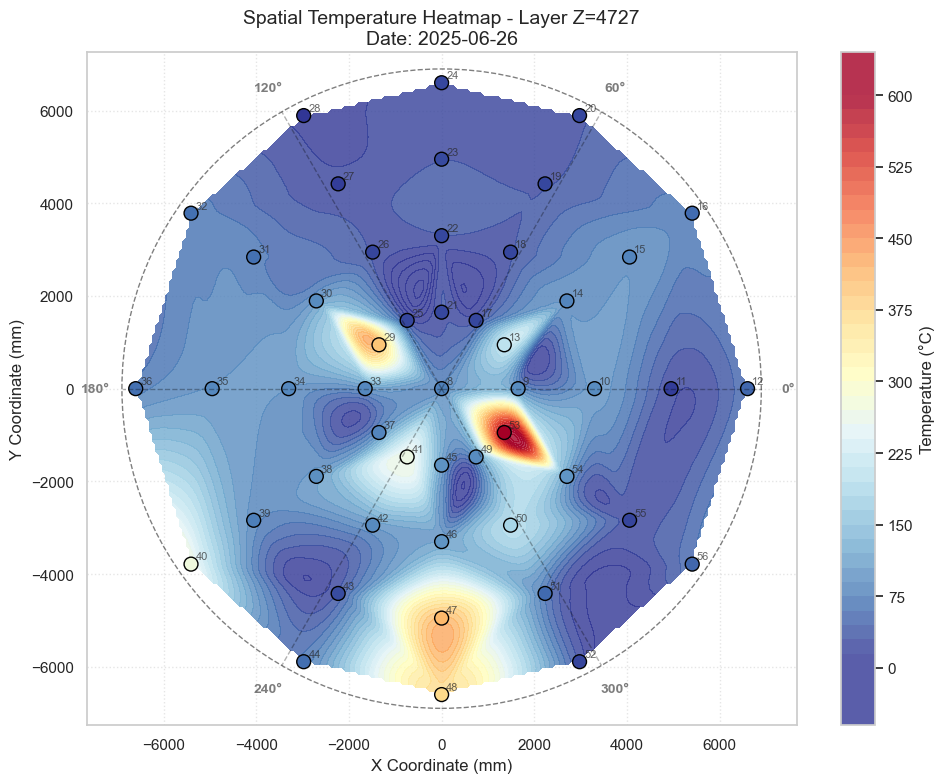


--- Analysis for Layer Z=4727 ---
Average Layer Temp: 106.4°C
Maximum Local Temp: 598.3°C (TC: 53 at [1351.6, -946.4])
Maximum Variance (Hotspot ΔT): 491.9°C above layer average.
--------------------------------------------------
Processing spatial map for Z=5177 on 2025-06-26...


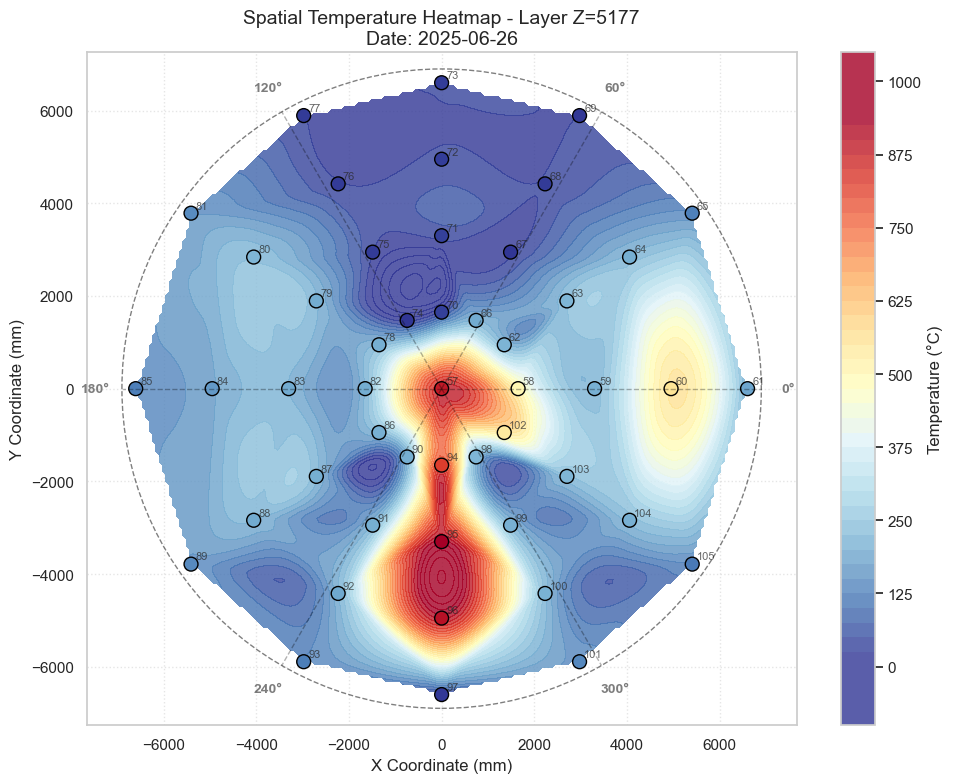


--- Analysis for Layer Z=5177 ---
Average Layer Temp: 228.0°C
Maximum Local Temp: 938.0°C (TC: 95 at [0.0, -3300.0])
Maximum Variance (Hotspot ΔT): 710.0°C above layer average.
--------------------------------------------------
Processing spatial map for Z=6177 on 2025-06-26...


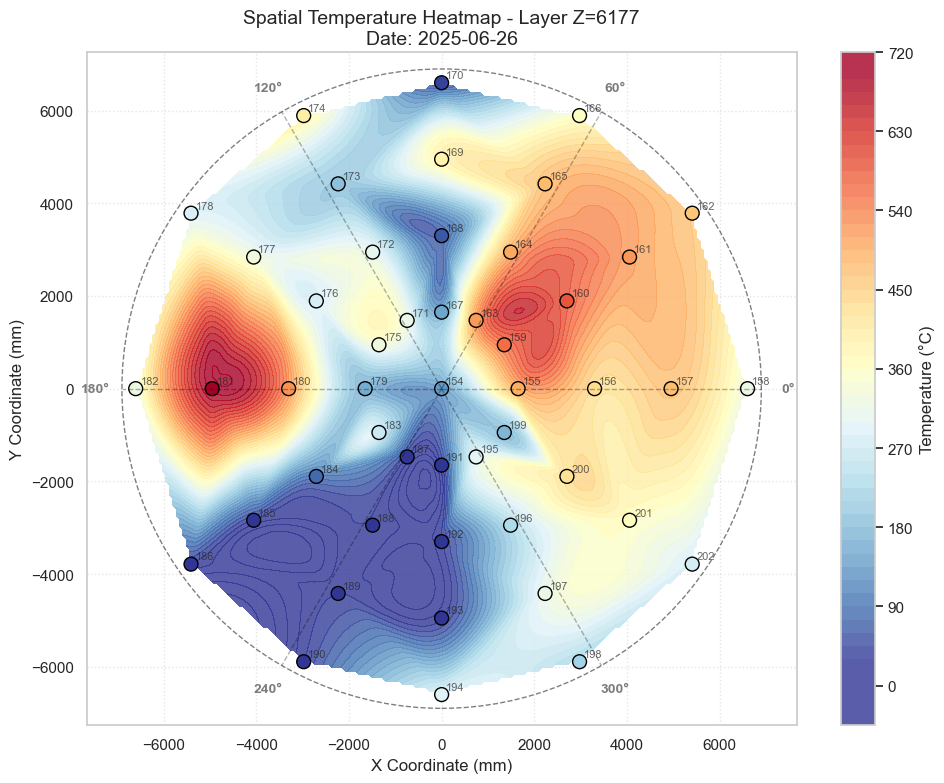


--- Analysis for Layer Z=6177 ---
Average Layer Temp: 281.9°C
Maximum Local Temp: 695.3°C (TC: 181 at [-4950.0, 0.0])
Maximum Variance (Hotspot ΔT): 413.4°C above layer average.
--------------------------------------------------


In [81]:
# Automatically pick the most recent date from the pivot table
if not layer_avg_pivot.empty:
    latest_date_pd = layer_avg_pivot.index.max()
    
    # Generate heatmaps for the specific bottom layers
    print(f"Generating 2D Spatial Analysis for latest date: {latest_date_pd.strftime('%Y-%m-%d')}")
    for z_layer in [4727, 5177, 6177]:
        plot_spatial_layer(latest_date_pd, z_layer)
        print("-" * 50)


## 1D Composite Stacked-Layer Erosion Prediction

This section calculates the theoretical **Remaining Refractory Thickness** of the topmost floor layer (High Alumina, Z=6177). 

Because the layers are stacked (Alumina -> Mullite -> Micropore Carbon), the liquid iron pool sits entirely on top of the Alumina layer. 
We calculate the true physical **Downward Heat Flux ($q$)** traveling between the $T_{6177}$ sensor and the $T_{5177}$ sensor below it. 
Using that unique daily $q$, we project the temperature *upwards* from the $T_{6177}$ sensor to determine exactly how many millimeters of Alumina remain before hitting the 1150°C iron boundary.

In [82]:
# 1D Heat Transfer Constants
k_mullite = 0.4    # W/mK
k_micropore = 10.0 # W/mK (Fixed for projection through TC layers)
k_graphite = 50.0  # W/mK
k_alumina = 1.0   # W/mK (High Alumina layer top-most)

# Accurate Z-levels and Layer Thicknesses (mm)
z_6177 = 6.177
z_5177 = 5.177
z_4727 = 4.727

# Refractory Stack above Z=6177 sensor
L_MULLITE = 460.0 # From 6177 to 6637
L_ALUMINA = 100.0 # From 6637 to 6737
TOTAL_STACK_ABOVE = L_MULLITE + L_ALUMINA

MC_THICKNESS = 600.0 # Used for caps on lower MC layers

T_CRITICAL = 1150.0  # Temperature of Liquid Pig Iron
RADIAL_LIMIT = 5200.0 # Exclude side wall sensors (r > 6600 - 1400)

# 1. Find vertically aligned TC triplets across the three layers
# Apply radial filter first
tc_pad = tc_meta[np.sqrt(tc_meta['X']**2 + tc_meta['Y']**2) <= RADIAL_LIMIT]

tc_6177_dict = tc_pad[tc_pad['Z'] == 6177].set_index(['X', 'Y'])['TC_ID'].to_dict()
tc_5177_dict = tc_pad[tc_pad['Z'] == 5177].set_index(['X', 'Y'])['TC_ID'].to_dict()
tc_4727_dict = tc_pad[tc_pad['Z'] == 4727].set_index(['X', 'Y'])['TC_ID'].to_dict()

# Find overlapping coordinates
common_coords = set(tc_6177_dict.keys()) & set(tc_5177_dict.keys()) & set(tc_4727_dict.keys())
aligned_tc_triplets = []
for coord in common_coords:
    aligned_tc_triplets.append({
        'top': tc_6177_dict[coord], 
        'mid': tc_5177_dict[coord],
        'bot': tc_4727_dict[coord]
    })
    
print(f"Found {len(aligned_tc_triplets)} vertically aligned TC triplets in the hearth pad.")

# 2. Aggregation
daily_temps_6177 = {}
daily_temps_5177 = {}
daily_temps_4727 = {}

id_6177 = [t['top'] for t in aligned_tc_triplets]
id_5177 = [t['mid'] for t in aligned_tc_triplets]
id_4727 = [t['bot'] for t in aligned_tc_triplets]

print("Scanning dataset for layer temperatures...")
reader = pd.read_csv(data_file, usecols=usecols, dtype=dtypes, chunksize=chunk_size)
for chunk in reader:
    chunk = chunk.rename(columns={id_col_data: 'TC_ID'})
    
    for layer_id, target_dict in zip([id_6177, id_5177, id_4727], 
                                     [daily_temps_6177, daily_temps_5177, daily_temps_4727]):
        c_layer = chunk[chunk['TC_ID'].isin(layer_id)]
        if not c_layer.empty:
            try: c_layer['DATE'] = pd.to_datetime(c_layer['MEASUREDATE'], format='%d-%m-%Y', errors='coerce').dt.date
            except: c_layer['DATE'] = pd.to_datetime(c_layer['MEASUREDATE'], errors='coerce').dt.date
            c_layer = c_layer.dropna(subset=['DATE', value_col])
            
            grouped = c_layer.groupby('DATE')[value_col].mean().to_dict()
            for d, t in grouped.items():
                if d not in target_dict or t > target_dict[d]:
                    target_dict[d] = t

print("Finished data aggregation.")

Found 37 vertically aligned TC triplets in the hearth pad.
Scanning dataset for layer temperatures...
Finished data aggregation.


In [83]:
# 3. Calculate Layered Heat Flux and Erosion
common_dates = sorted(list(set(daily_temps_6177.keys()) & set(daily_temps_5177.keys()) & set(daily_temps_4727.keys())))

dates = []
rem_6177 = []
rem_5177 = []
rem_4727 = []

# Distances between sensors in meters for flux calculation
dist_6177_5177_m = (z_6177 - z_5177) 
dist_5177_4727_m = (z_5177 - z_4727)

# Pre-calculate Max Thermal Resistance of the layers above 6177
R_alumina_max = (L_ALUMINA / 1000.0) / k_alumina
R_mullite_max = (L_MULLITE / 1000.0) / k_mullite

for d in common_dates:
    T6 = daily_temps_6177[d]
    T5 = daily_temps_5177[d]
    T4 = daily_temps_4727[d]
    
    if not (T6 > T5 > T4): # Basic gradient check
        continue
        
    # q (downwards) between 6177 and 5177 (through Micropore Carbon)
    q_top = k_micropore * (T6 - T5) / dist_6177_5177_m # q in W/m2
    
    # Layer 6177 Erosion: Project upwards from the sensor
    # R_total_needed is the resistance from T_CRITICAL (top) down to T6 (sensor)
    R_total_needed = (T_CRITICAL - T6) / q_top if q_top > 0 else 0
    
    # --- LOGIC CHANGE START ---
    # Heat sequence: High Alumina (top) -> Mullite (above sensor)
    # If the required resistance is VERY high, it's in the Alumina.
    # If the resistance is LOW, the Alumina is gone and the isotherm is in the Mullite.
    
    if R_total_needed > R_mullite_max:
        # Isotherm is in the High Alumina layer (Mullite is fully intact)
        R_remaining_in_alumina = R_total_needed - R_mullite_max
        L6 = L_MULLITE + (R_remaining_in_alumina * k_alumina * 1000.0)
    else:
        # High Alumina is GONE; isotherm is inside the Mullite layer
        L6 = R_total_needed * k_mullite * 1000.0
    # --- LOGIC CHANGE END ---
        
    # Cap at total physical thickness (560mm)
    rem_6177.append(min(TOTAL_STACK_ABOVE, max(0, L6)))
    
    # Layer 5177 Erosion: Project into Micropore above 5177
    L5 = (((T_CRITICAL - T5) * k_micropore) / q_top) * 1000.0 if q_top > 0 else 0
    rem_5177.append(min(MC_THICKNESS, max(0, L5)))
    
    # q (downwards) between 5177 and 4727 (through Micropore Carbon)
    q_mid = k_micropore * (T5 - T4) / dist_5177_4727_m # q in W/m2
    
    # Layer 4727 Erosion: Project into Micropore above 4727
    L4 = (((T_CRITICAL - T4) * k_micropore) / q_mid) * 1000.0 if q_mid > 0 else 0
    rem_4727.append(min(MC_THICKNESS, max(0, L4)))
    
    dates.append(pd.to_datetime(d))

df_erosion = pd.DataFrame({
    'Date': dates, 
    'L6177_Composite': rem_6177, 
    'L5177_Micropore': rem_5177, 
    'L4727_Micropore': rem_4727
})
df_erosion = df_erosion.sort_values('Date')

# Smoothing
for col in ['L6177_Composite', 'L5177_Micropore', 'L4727_Micropore']:
    df_erosion[f'Smoothed_{col}'] = df_erosion[col].rolling(window=60, min_periods=10).mean()

print("Layered Composite Erosion Time-Series calculated with corrected Alumina-Mullite logic.")

Layered Composite Erosion Time-Series calculated with corrected Alumina-Mullite logic.


Diagnostic: L6177_Composite has 1628 non-NaN smoothed points
Diagnostic: L5177_Micropore has 1628 non-NaN smoothed points
Diagnostic: L4727_Micropore has 1628 non-NaN smoothed points


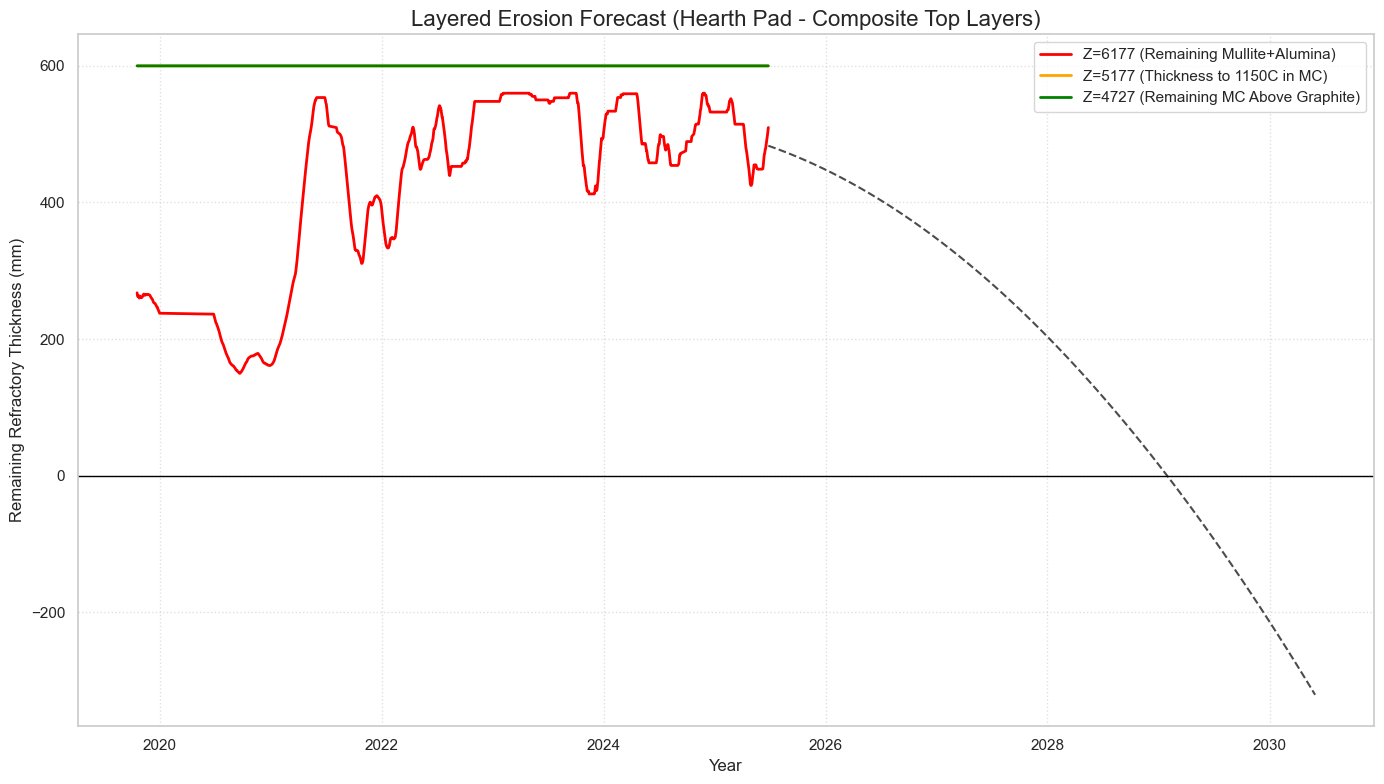

In [84]:
# 4. Multi-Layer Erosion Forecast
def predict_multi_layer_erosion(df):
    plt.figure(figsize=(14, 8))
    colors = {'L6177_Composite': 'red', 'L5177_Micropore': 'orange', 'L4727_Micropore': 'green'}
    labels = {
        'L6177_Composite': 'Z=6177 (Remaining Mullite+Alumina)', 
        'L5177_Micropore': 'Z=5177 (Thickness to 1150C in MC)', 
        'L4727_Micropore': 'Z=4727 (Remaining MC Above Graphite)'
    }
    
    for col, color in colors.items():
        smooth_col = f'Smoothed_{col}'
        df_clean = df.dropna(subset=[smooth_col]).copy()
        print(f'Diagnostic: {col} has {len(df_clean)} non-NaN smoothed points')
        if len(df_clean) < 50: continue
        
        plt.plot(df_clean['Date'], df_clean[smooth_col], color=color, linewidth=2, label=labels[col])
        
        # Simple polynomial extrapolation for the top layer (Target Layer)
        if col == 'L6177_Composite':
            start_date = df_clean['Date'].min()
            days = (df_clean['Date'] - start_date).dt.days
            x = days.values
            y = df_clean[smooth_col].values
            popt, _ = curve_fit(lambda x, a, b, c: a*x**2 + b*x + c, x, y)
            
            future_days = np.arange(x.max(), x.max() + (365 * 5), 30)
            future_dates = [start_date + datetime.timedelta(days=int(d)) for d in future_days]
            future_y = popt[0]*future_days**2 + popt[1]*future_days + popt[2]
            plt.plot(future_dates, future_y, color='black', linestyle='--', alpha=0.7)

    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    plt.title("Layered Erosion Forecast (Hearth Pad - Composite Top Layers)", fontsize=16)
    plt.ylabel("Remaining Refractory Thickness (mm)", fontsize=12)
    plt.xlabel("Year", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

predict_multi_layer_erosion(df_erosion)

## 5. Sideways Wall Erosion Analysis (Z=6177 to 7000)

This section calculates the theoretical **Sideways Remaining Wall Thickness** for the furnace wall (Micropore Carbon). 
We use radial sensor triplets at the HW1 layer (Z=6637) to determine the radial heat flux ($q_r$) and project the 1150°C isotherm inward from the innermost sensor.
**Note**: The maximum wall thickness is physicaly capped at 1350 mm.

In [85]:
# 5.1 Configuration: Radial Groups and Material Properties
k_wall = 10.0 # Micropore Carbon W/mK
T_CRITICAL = 1150.0
R_SHELL = 7440.0 # Approximate shell radius
MAX_THICKNESS = 1350.0 # Maximum physical wall thickness

# Ensure tc_meta has R and theta
if 'R' not in tc_meta.columns:
    tc_meta['R'] = np.sqrt(tc_meta['X']**2 + tc_meta['Y']**2)
if 'theta' not in tc_meta.columns:
    tc_meta['theta'] = np.degrees(np.arctan2(tc_meta['Y'], tc_meta['X']))
    tc_meta['theta'] = (tc_meta['theta'] + 360) % 360

# Define radial triplets at HW1 (Z=6637)
wall_triplets = []
for i in range(203, 239, 3):
    group_ids = [i, i+1, i+2]
    try:
        radii = [tc_meta[tc_meta['TC_ID'] == tid]['R'].values[0] for tid in group_ids]
        theta = tc_meta[tc_meta['TC_ID'] == group_ids[0]]['theta'].values[0]
        wall_triplets.append({'ids': group_ids, 'R': radii, 'theta': theta})
    except IndexError:
        continue

wall_sensor_ids = [tid for group in wall_triplets for tid in group['ids']]
print(f"Tracking {len(wall_triplets)} radial triplets for sideways erosion analysis at Z=6637.")

Tracking 12 radial triplets for sideways erosion analysis at Z=6637.


In [86]:
# 5.2 Aggregation for Wall Sensors
daily_wall_temps = {tid: {} for tid in wall_sensor_ids}

print("Scanning dataset for wall temperatures in chunks...")
reader = pd.read_csv(data_file, usecols=usecols, dtype=dtypes, chunksize=chunk_size)
for chunk in reader:
    chunk = chunk.rename(columns={id_col_data: 'TC_ID'})
    c_wall = chunk[chunk['TC_ID'].isin(wall_sensor_ids)]
    if not c_wall.empty:
        try: c_wall['DATE'] = pd.to_datetime(c_wall['MEASUREDATE'], format='%d-%m-%Y', errors='coerce').dt.date
        except: c_wall['DATE'] = pd.to_datetime(c_wall['MEASUREDATE'], errors='coerce').dt.date
        c_wall = c_wall.dropna(subset=['DATE', value_col])
        grouped = c_wall.groupby(['DATE', 'TC_ID'])[value_col].mean().reset_index()
        for _, row in grouped.iterrows():
            daily_wall_temps[row['TC_ID']][row['DATE']] = row[value_col]

print("Finished wall data aggregation.")

Scanning dataset for wall temperatures in chunks...
Finished wall data aggregation.


In [87]:
# 5.3 Calculate Sideways Erosion with 1350mm Cap
for group in wall_triplets:
    t_ids = group['ids']
    t_radii = group['R']
    id1, id2 = t_ids[0], t_ids[1]
    r1, r2 = t_radii[0], t_radii[1]
    dr = r2 - r1
    common_dates = sorted(list(set(daily_wall_temps[id1].keys()) & set(daily_wall_temps[id2].keys())))
    erosion_data = []
    for d in common_dates:
        temp1 = daily_wall_temps[id1][d]
        temp2 = daily_wall_temps[id2][d]
        if temp1 > temp2 and temp1 > 100:
            qr = k_wall * (temp1 - temp2) / dr
            # Project inward from sensor 1 to 1150C boundary radius
            r_eroded = r1 - (k_wall * (T_CRITICAL - temp1) / qr)
            # Apply 1350mm max thickness cap
            rem_thickness = min(MAX_THICKNESS, R_SHELL - r_eroded)
            erosion_data.append({'Date': d, 'RemThickness': rem_thickness})
    group['erosion_df'] = pd.DataFrame(erosion_data)

print(f"Sideways erosion calculation completed with {MAX_THICKNESS}mm cap.")

Sideways erosion calculation completed with 1350.0mm cap.


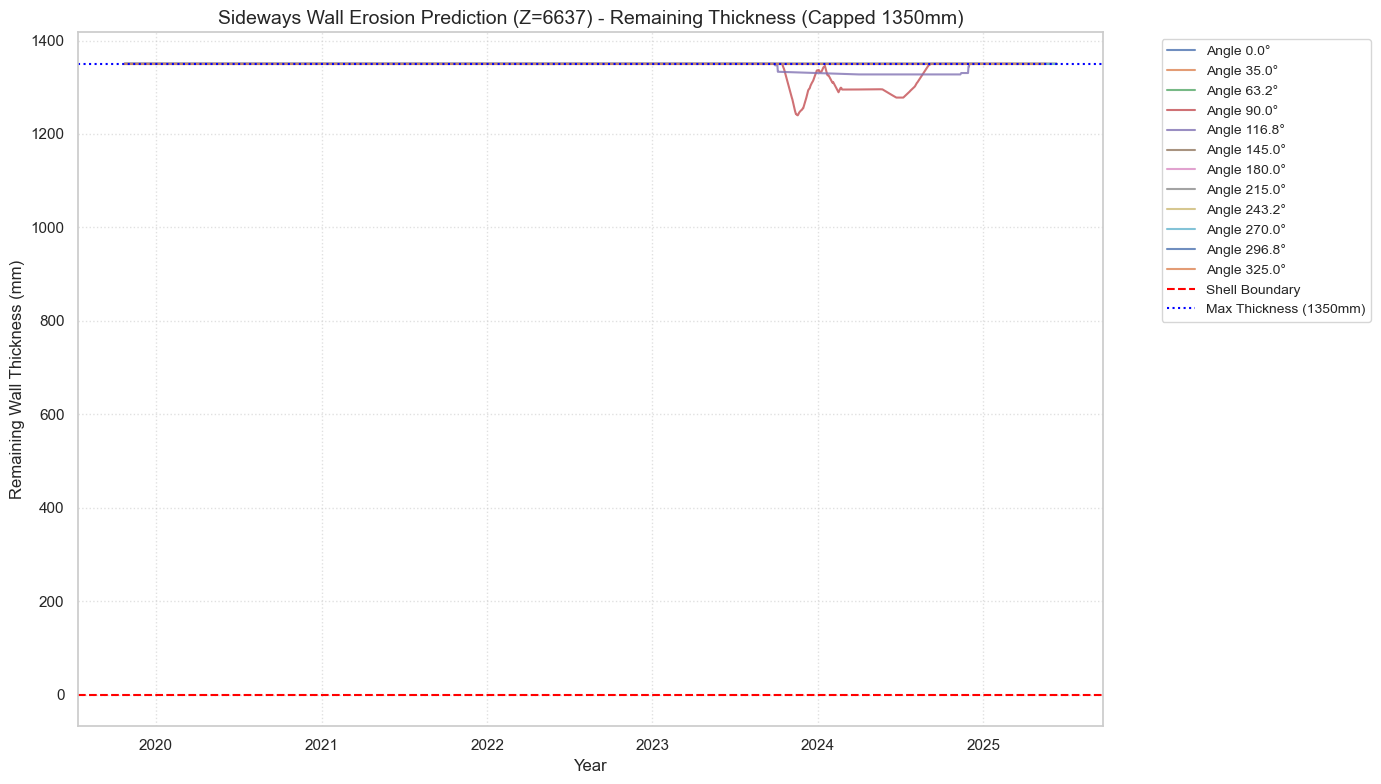

In [88]:
# 5.4 Visualization: Sideways Erosion Trends
plt.figure(figsize=(14, 8))
for group in wall_triplets:
    df_e = group.get('erosion_df')
    if df_e is not None and not df_e.empty:
        df_e = df_e.sort_values('Date').copy()
        df_e['Date'] = pd.to_datetime(df_e['Date'])
        # 30-day smoothing
        df_e['Smoothed'] = df_e['RemThickness'].rolling(window=30, center=True).mean()
        plt.plot(df_e['Date'], df_e['Smoothed'], label=f"Angle {group['theta']:.1f}°", alpha=0.8)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Shell Boundary')
plt.axhline(y=MAX_THICKNESS, color='blue', linestyle=':', label='Max Thickness (1350mm)')
plt.title("Sideways Wall Erosion Prediction (Z=6637) - Remaining Thickness (Capped 1350mm)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Remaining Wall Thickness (mm)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Angular Hearth Pad Erosion Analysis (Faceted View)

This section breaks down the hearth pad erosion into six 60° sectors and compares the erosion depth across three layers: 
1. **Z=6177 (Top)**: Remaining Mullite + Alumina.
2. **Z=5177 (Mid)**: Thickness to 1150°C within Micropore Carbon.
3. **Z=4727 (Bot)**: Thickness to 1150°C within Micropore Carbon.

Visualizing these together in a faceted grid allows for easy identification of vertical erosion progress in each specific quadrant.

In [89]:
# 6.1 Configuration: Sector Bins and Sensor Grouping
RADIAL_LIMIT = 5200.0
sector_bins = [0, 60, 120, 180, 240, 300, 360]
sector_labels = [f"{sector_bins[i]}-{sector_bins[i+1]}°" for i in range(len(sector_bins)-1)]

# Group all pad sensors into 6 sectors
pad_meta = tc_meta[np.sqrt(tc_meta['X']**2 + tc_meta['Y']**2) <= RADIAL_LIMIT].copy()
if 'theta' not in pad_meta.columns:
    pad_meta['theta'] = np.degrees(np.arctan2(pad_meta['Y'], pad_meta['X']))
    pad_meta['theta'] = (pad_meta['theta'] + 360) % 360

pad_meta['sector'] = pd.cut(pad_meta['theta'], bins=sector_bins, labels=range(6), include_lowest=True)

sector_sensor_map = {}
all_hearth_sector_ids = []
for s_idx in range(6):
    sector_sensor_map[s_idx] = {}
    for z in [6177, 5177, 4727]:
        ids = pad_meta[(pad_meta['sector'] == s_idx) & (pad_meta['Z'] == z)]['TC_ID'].tolist()
        sector_sensor_map[s_idx][z] = ids
        all_hearth_sector_ids.extend(ids)

print(f"Grouped hearth sensors into {len(sector_labels)} sectors for multi-layer analysis.")

Grouped hearth sensors into 6 sectors for multi-layer analysis.


In [90]:
# 6.2 Aggregation for Hearth Sectors
sector_daily_temps = {s_idx: {z: {} for z in [6177, 5177, 4727]} for s_idx in range(6)}

print("Scanning dataset for floor temperatures (chunked)...")
reader = pd.read_csv(data_file, usecols=usecols, dtype=dtypes, chunksize=chunk_size)
for chunk in reader:
    chunk = chunk.rename(columns={id_col_data: 'TC_ID'})
    c_pad = chunk[chunk['TC_ID'].isin(all_hearth_sector_ids)]
    if not c_pad.empty:
        try: c_pad['DATE'] = pd.to_datetime(c_pad['MEASUREDATE'], format='%d-%m-%Y', errors='coerce').dt.date
        except: c_pad['DATE'] = pd.to_datetime(c_pad['MEASUREDATE'], errors='coerce').dt.date
        c_pad = c_pad.dropna(subset=['DATE', value_col])
        for s_idx in range(6):
            for z in [6177, 5177, 4727]:
                z_ids = sector_sensor_map[s_idx][z]
                c_sub = c_pad[c_pad['TC_ID'].isin(z_ids)]
                if not c_sub.empty:
                    grouped = c_sub.groupby('DATE')[value_col].mean().to_dict()
                    for d, t in grouped.items():
                        if d not in sector_daily_temps[s_idx][z] or t > sector_daily_temps[s_idx][z][d]:
                            sector_daily_temps[s_idx][z][d] = t

print("Finished angular hearth data aggregation.")

Scanning dataset for floor temperatures (chunked)...
Finished angular hearth data aggregation.


In [94]:
# 6.3 Calculate Multi-Layer Angular Erosion
sector_erosion_results = {}

for s_idx in range(6):
    s_temps = sector_daily_temps[s_idx]
    # Get common dates across all 3 layers for consistency
    common_dates = sorted(list(set(s_temps[6177].keys()) & set(s_temps[5177].keys()) & set(s_temps[4727].keys())))
    
    erosion_data = []
    for d in common_dates:
        t6177, t5177, t4727 = s_temps[6177][d], s_temps[5177][d], s_temps[4727][d]
    
        # 1. Correct Flux: Between 6177 and 5177 is Micropore Carbon
        # Result in W/m2
        q = k_micropore * (t6177 - t5177) / (z_6177 - z_5177)
        
        if q <= 0: continue
    
        # 2. Z=6177 Boundary (Mullite then Alumina)
        # Calculate resistance needed to reach T_CRITICAL from T6177
        R_needed = (T_CRITICAL - t6177) / q
        R_mullite_max = (L_MULLITE / 1000.0) / k_mullite
        
        if R_needed < R_mullite_max:
            # Isotherm is in Mullite
            rem_6177 = R_needed * k_mullite * 1000.0 # Convert to mm
        else:
            # Mullite is full, isotherm is in Alumina
            R_rem_alumina = R_needed - R_mullite_max
            L_a_rem = min(L_ALUMINA, R_rem_alumina * k_alumina * 1000.0)
            rem_6177 = L_MULLITE + L_a_rem
    
        # 3. Z=5177 and Z=4727 Boundaries (Micropore Carbon)
        # Flux for lower layers
        q_mc = k_micropore * (t5177 - t4727) / (z_5177 - z_4727)
        
        if q_mc > 0:
            # Distance (mm) = (Temp Diff * k / flux) * 1000
            rem_5177 = min(MC_THICKNESS, ((T_CRITICAL - t5177) * k_micropore / q_mc) * 1000.0)
            rem_4727 = min(MC_THICKNESS, ((T_CRITICAL - t4727) * k_micropore / q_mc) * 1000.0)
        else:
            rem_5177, rem_4727 = MC_THICKNESS, MC_THICKNESS
    
        erosion_data.append({'Date': d, 'Rem_6177': rem_6177, 'Rem_5177': rem_5177, 'Rem_4727': rem_4727})
    
    sector_erosion_results[s_idx] = pd.DataFrame(erosion_data)

print("Angular hearth multi-layer erosion calculation completed.")

Angular hearth multi-layer erosion calculation completed.


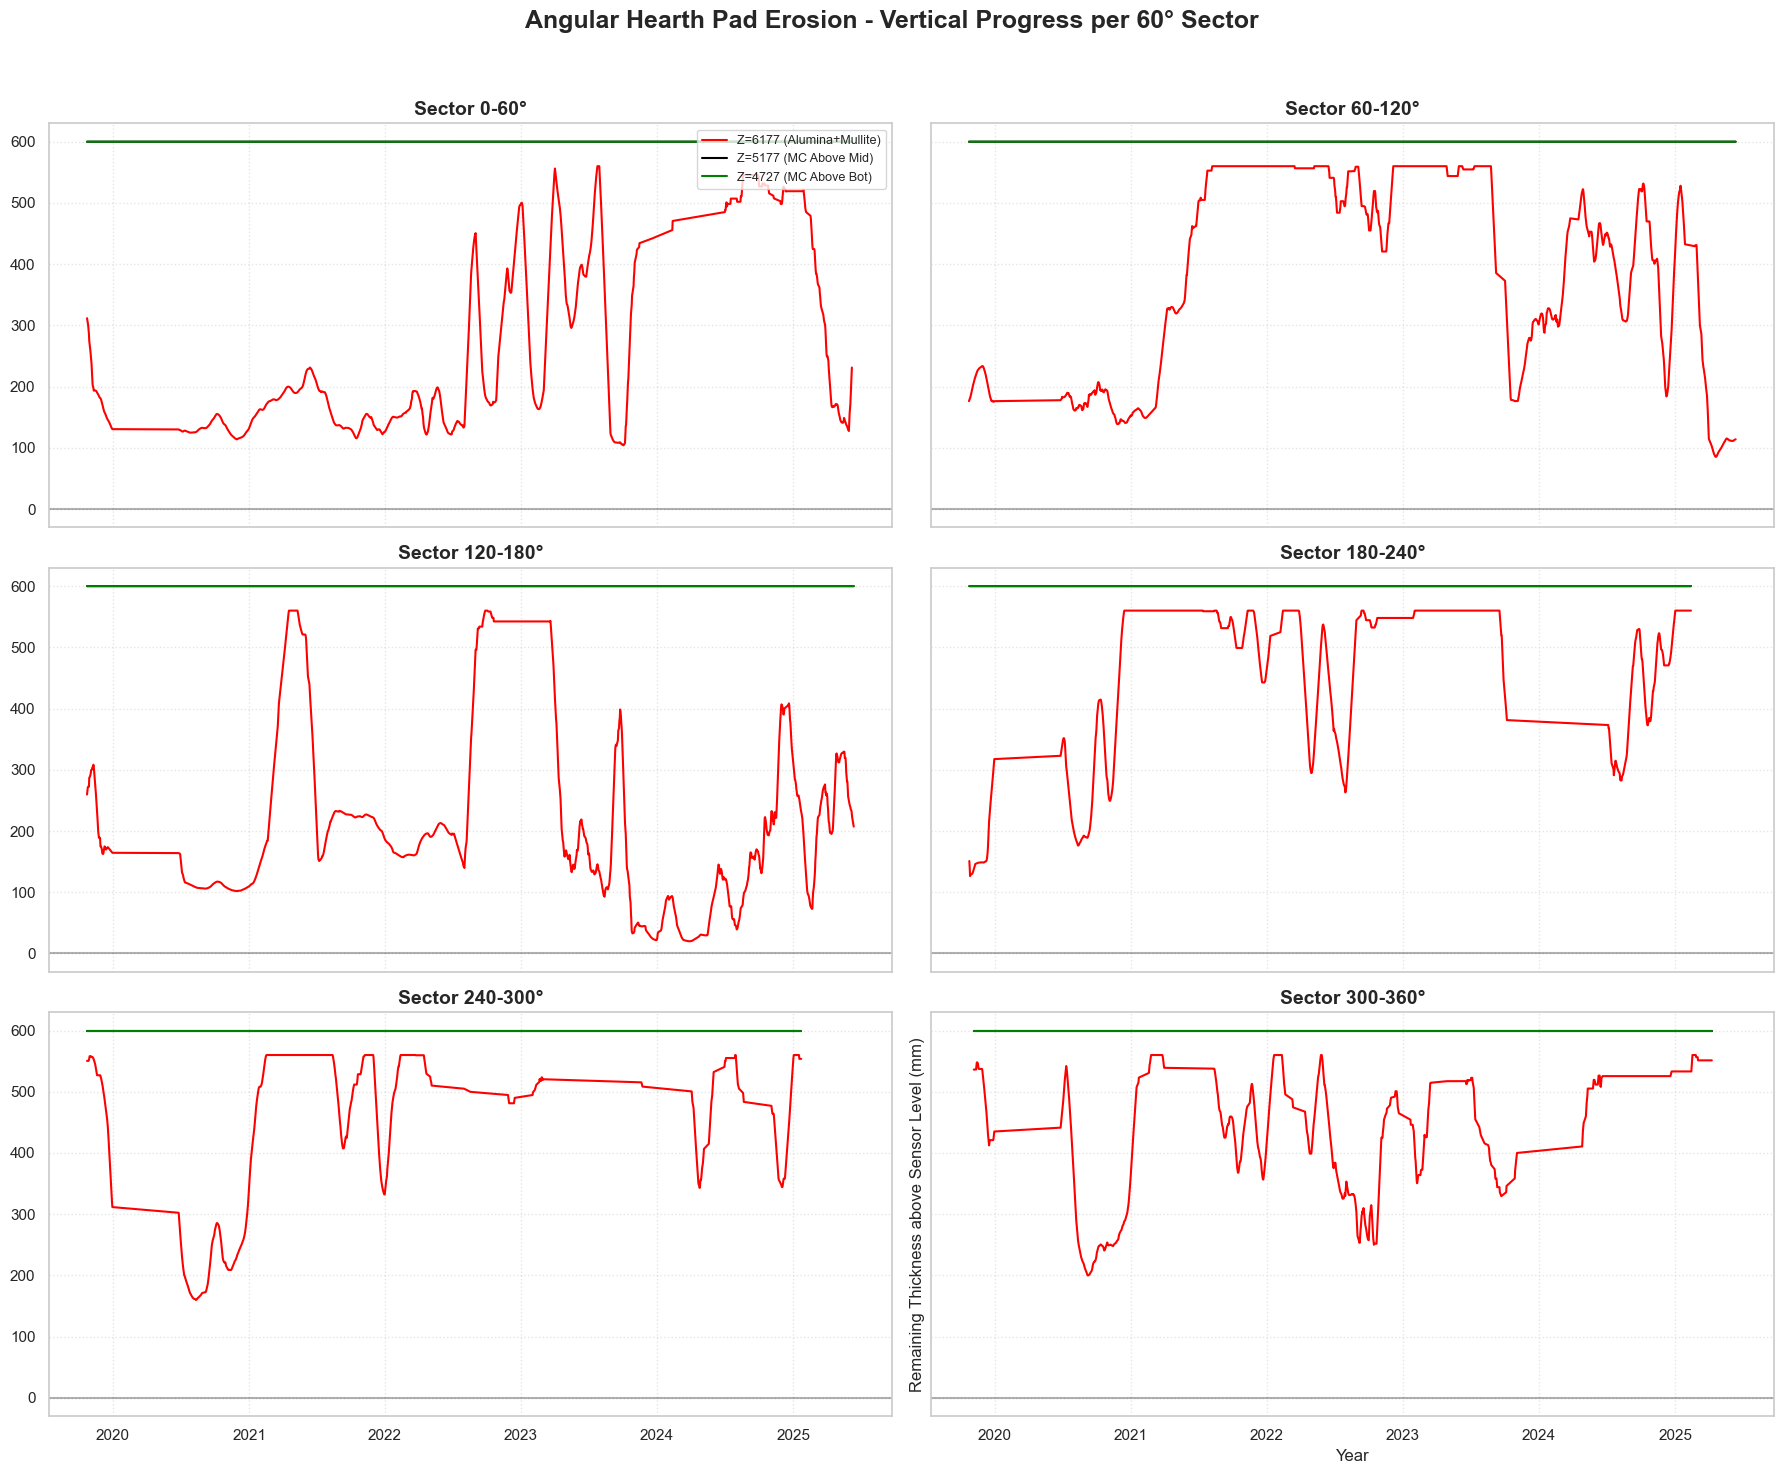

In [96]:
# 6.4 Faceted Visualization: Sector-Wise Multi-Layer Erosion
fig, axes = plt.subplots(3, 2, figsize=(18, 16), sharex=True, sharey=True)
axes = axes.flatten()

for s_idx in range(6):
    ax = axes[s_idx]
    df_e = sector_erosion_results[s_idx]
    if not df_e.empty:
        df_e = df_e.sort_values('Date').copy()
        df_e['Date'] = pd.to_datetime(df_e['Date'])
        # Smoothing and Plotting
        for col, color, label in [('Rem_6177', 'red', 'Z=6177 (Alumina+Mullite)'),
                                  ('Rem_5177', 'black', 'Z=5177 (MC Above Mid)'),
                                  ('Rem_4727', 'green', 'Z=4727 (MC Above Bot)')]:
            df_e[f'Smoothed_{col}'] = df_e[col].rolling(window=30, center=True).mean()
            ax.plot(df_e['Date'], df_e[f'Smoothed_{col}'], color=color, label=label, linewidth=1.5)

    ax.set_title(f"Sector {sector_labels[s_idx]}", fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax.grid(True, linestyle=':', alpha=0.5)
    if s_idx == 0: ax.legend(loc='upper right', fontsize=9)

fig.suptitle("Angular Hearth Pad Erosion - Vertical Progress per 60° Sector", fontsize=18, fontweight='bold', y=0.95)
plt.xlabel("Year")
plt.ylabel("Remaining Thickness above Sensor Level (mm)")
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()